# Project Title: Economic Stress Testing & Credit Risk Intelligence Platform

# Business Problem: Financial institutions face increased credit risk during periods of economic uncertainty. Traditional lending models often fail to account for changing macroeconomic conditions, resulting in higher default rates and financial losses.

# Project Objective: Develop a predictive analytics platform that estimates borrower default probability and evaluates portfolio performance under varying economic stress scenarios using macroeconomic indicators.

# Stakeholders / Beneficiaries:
#    - Banks and lending institutions
#    - Credit risk analysts
#    - Portfolio managers
#    - Investors
#    - Regulatory agencies

# Key Business Decisions Supported:
#    - Loan approval and rejection
#    - Credit limit determination
#    - Risk-based pricing
#    - Portfolio risk management
#    - Economic stress-testing strategies

#    - Business Value
#    - Reduce expected credit losses
#    - Improve lending decisions
#    - Enhance portfolio resilience
#    - Strengthen risk management practices

#    - Success Metrics
#    - ROC-AUC > 0.75
#    - High recall for default loans
#    - Accurate stress-testing results
#    - Improved identification of high-risk borrowers


# Executive Summary

This project develops a Credit Risk Intelligence Platform that predicts loan default risk and evaluates portfolio resilience under changing economic conditions.

Using over 1.3 million Lending Club loans and macroeconomic indicators from the Federal Reserve, machine learning models were developed to estimate default probability and assess risk under economic stress scenarios.

Key Findings:

- Overall default rate: 19.98%
- Logistic Regression ROC-AUC: 0.648
- Random Forest ROC-AUC: 0.662
- FICO score was the strongest protective factor.
- Loan amount and debt-to-income ratio were the strongest risk factors.
- Economic stress testing demonstrated how portfolio risk can be evaluated under adverse economic conditions.

# Economic Stress Testing & Credit Risk Intelligence Platform

## Project Structure

```text
Economic_Stress_Testing_Project/
│
├── data/
│   ├── raw/
│   │   ├── LC_loans_granting_model_dataset.csv
│   │   ├── unrate.csv
│   │   ├── fedfunds.csv
│   │   └── cpiaucs.csv
│   │
│   └── processed/
│       └── loan_merged.csv
│
├── notebooks/
│   ├── 01_Data_Preparation.ipynb
│   ├── 02_Exploratory_Data_Analysis.ipynb
│   ├── 03_Feature_Engineering.ipynb
│   ├── 04_Model_Development.ipynb
│   └── 05_Economic_Stress_Testing.ipynb
│
├── models/
│   ├── logistic_regression.pkl
│   ├── random_forest.pkl
│   └── xgboost.pkl
│
├── outputs/
│   ├── figures/
│   ├── tables/
│   ├── reports/
│   └── stress_test_results.csv
│
├── requirements.txt
├── README.md
└── .gitignore
```

## Folder Descriptions

### data/
Stores all datasets used throughout the project.

#### raw/
Contains the original, unmodified datasets:

- `LC_loans_granting_model_dataset.csv`
- `unrate.csv`
- `fedfunds.csv`
- `cpiaucs.csv`

#### processed/
Contains cleaned and merged datasets created during preprocessing.

Example:
- `loan_merged.csv`

---

### notebooks/
Contains Jupyter notebooks organized by project phase.

1. **01_Data_Preparation.ipynb**
   - Load datasets
   - Clean data
   - Handle missing values
   - Merge macroeconomic indicators

2. **02_Exploratory_Data_Analysis.ipynb**
   - Distribution analysis
   - Correlation analysis
   - Default rate exploration

3. **03_Feature_Engineering.ipynb**
   - Debt-to-Income Ratio (DTI)
   - FICO categorization
   - Economic Stress Index creation

4. **04_Model_Development.ipynb**
   - Logistic Regression
   - Random Forest
   - XGBoost
   - Model evaluation

5. **05_Economic_Stress_Testing.ipynb**
   - Scenario analysis
   - Economic stress simulations
   - Portfolio risk assessment

---

### models/
Stores trained machine learning models.

Examples:
- `logistic_regression.pkl`
- `random_forest.pkl`
- `xgboost.pkl`

---

### outputs/
Stores all project outputs.

#### figures/
Charts and visualizations.

#### tables/
Summary statistics and evaluation tables.

#### reports/
Business reports and project summaries.

#### stress_test_results.csv
Results from economic stress-testing scenarios.

---

### requirements.txt
Lists all Python packages required to run the project.

Example:

```text
pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
statsmodels
fredapi
```

---

### README.md
Provides project overview, objectives, methodology, results, and instructions for reproducing the analysis.

---

### .gitignore
Prevents unnecessary files from being uploaded to GitHub.

Example:

```text
.ipynb_checkpoints/
__pycache__/
*.pkl
.DS_Store
```

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Setup Complete")

Setup Complete


In [5]:
# Load datasets

loan = pd.read_csv("../data/LC_loans_granting_model_dataset.csv", low_memory=False)

unrate = pd.read_csv("../data/unrate.csv")
fedfunds = pd.read_csv("../data/fedfunds.csv")
cpiaucs = pd.read_csv("../data/cpiaucs.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [6]:
# Verify dataset dimensions

print(f"Loan Dataset Shape: {loan.shape}")
print(f"UNRATE Dataset Shape: {unrate.shape}")
print(f"FEDFUNDS Dataset Shape: {fedfunds.shape}")
print(f"CPI Dataset Shape: {cpiaucs.shape}")


Loan Dataset Shape: (1347681, 15)
UNRATE Dataset Shape: (941, 2)
FEDFUNDS Dataset Shape: (863, 2)
CPI Dataset Shape: (952, 2)


In [7]:
# Review target variable

print("Default Status Counts:")
print(loan['Default'].value_counts())

# Review date coverage

print("\nLoan Date Coverage:")
print("Start Date:", loan['issue_d'].min())
print("End Date:", loan['issue_d'].max())

Default Status Counts:
Default
0    1078432
1     269249
Name: count, dtype: int64

Loan Date Coverage:
Start Date: Apr-2008
End Date: Sep-2018


## Review Data Types

In this step, we examine the data types of each variable to identify numeric, categorical, and date fields. This helps determine what preprocessing steps will be required before modeling.

In [9]:
# Review data types
loan.dtypes

# Count data types
loan.dtypes.value_counts()

object     8
int64      4
float64    3
Name: count, dtype: int64

## Review Missing Values

Missing values can impact model performance and must be identified before data preparation. This step helps determine which variables require cleaning, imputation, or removal.

In [11]:
# Missing value percentages

missing_pct = (loan.isnull().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].head(20)
loan = loan.drop(columns=['title', 'desc', 'zip_code'], errors='ignore')

In [12]:
# Dataset overview

print("Shape:", loan.shape)
loan.head()

Shape: (1347681, 12)


,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,Default
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,0
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,0
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,0
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,0
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,0


## Key Variables

| Variable | Description |
|-----------|------------|
| loan_amnt | Original loan amount |
| revenue | Borrower annual income |
| fico_n | Borrower FICO score |
| dti_n | Debt-to-income ratio |
| loan_to_income | Loan amount divided by income |
| Default | Target variable (0 = Non-default, 1 = Default) |
| UNRATE | U.S. unemployment rate |
| FEDFUNDS | Federal Funds Rate |
| CPIAUCSL | Consumer Price Index |
| Economic_Stress_Index | Composite macroeconomic stress measure |

# Phase 2: Data Cleaning & Preparation
## Goal: The purpose of this phase is to clean and prepare the data for analysis and predictive modeling.

## Tasks
1. Convert date variables to datetime format.
2. Standardize date fields across datasets.
3. Handle missing values.
4. Select relevant variables.
5. Create the target variable (Default).
6. Merge loan and macroeconomic datasets.
7. Create modeling-ready features.

## Expected Outcome
By the end of this phase, we will have a clean, merged dataset ready for exploratory analysis and machine learning.

In [15]:
# Force all column names to lowercase across macro dataframes to prevent KeyErrors
unrate.columns = unrate.columns.str.lower()
fedfunds.columns = fedfunds.columns.str.lower()
cpiaucs.columns = cpiaucs.columns.str.lower()

# Verify the changes by printing the new columns
print("Unrate columns:", unrate.columns.tolist())
print("Fedfunds columns:", fedfunds.columns.tolist())
print("CPI columns:", cpiaucs.columns.tolist())

Unrate columns: ['observation_date', 'unrate']
Fedfunds columns: ['observation_date', 'fedfunds']
CPI columns: ['observation_date', 'cpiaucsl']


In [16]:
# 1. Safely convert loan issue date
loan['issue_d'] = pd.to_datetime(loan['issue_d'], format='mixed')

# 2. Dynamically find and rename any date column in macro dataframes
for df, name in zip([unrate, fedfunds, cpiaucs], ['unrate', 'fedfunds', 'cpiaucs']):
    # Find any column that has 'date' in it (e.g., 'DATE', 'date', 'observation_date')
    date_col = [col for col in df.columns if 'date' in col.lower()]
    
    if date_col:
        # Rename it explicitly to 'date'
        df.rename(columns={date_col[0]: 'date'}, inplace=True)
        # Convert it to datetime
        df['date'] = pd.to_datetime(df['date'])
    else:
        raise KeyError(f"Could not find a date column in the {name} dataset. Available columns: {df.columns.tolist()}")

print("Date conversion complete with zero errors or warnings!")

Date conversion complete with zero errors or warnings!


In [17]:
# 1. Handle the loan issue date cleanly
loan['issue_d'] = pd.to_datetime(loan['issue_d'], format='mixed')
# Create the standardized monthly timestamp for merging
loan['date'] = loan['issue_d'].dt.to_period('M').dt.to_timestamp()

# 2. Dynamically clean and convert macroeconomic dates
macro_dfs = {'unrate': unrate, 'fedfunds': fedfunds, 'cpiaucs': cpiaucs}

for name, df in macro_dfs.items():
    # Dynamically look for any column containing 'date' (case-insensitive)
    date_col = [col for col in df.columns if 'date' in col.lower()]
    
    if date_col:
        # Standardize the column name to exactly 'date'
        df.rename(columns={date_col[0]: 'date'}, inplace=True)
        # Convert it to a proper datetime object
        df['date'] = pd.to_datetime(df['date'])
    else:
        raise KeyError(f"Could not find a date column in the '{name}' dataset. Available columns: {df.columns.tolist()}")

print("Date conversion and keys successfully standardized!")

Date conversion and keys successfully standardized!


In [18]:
# 1. Dynamically identify the macro economic feature names (handling lowercase/uppercase variations)
unrate_feat = [col for col in unrate.columns if col != 'date'][0]
fedfunds_feat = [col for col in fedfunds.columns if col != 'date'][0]
cpiaucs_feat = [col for col in cpiaucs.columns if col != 'date'][0]

# 2. Progressively merge based on our standardized 'date' key using dynamic names (FIXED: Quotations removed)
loan_merged = loan.merge(unrate[['date', unrate_feat]], on='date', how='left')
loan_merged = loan_merged.merge(fedfunds[['date', fedfunds_feat]], on='date', how='left')
loan_merged = loan_merged.merge(cpiaucs[['date', cpiaucs_feat]], on='date', how='left')

# 3. Standardize the merged columns to exact uppercase for your upcoming Economic Stress Index calculations
loan_merged.rename(columns={
    unrate_feat: 'UNRATE',
    fedfunds_feat: 'FEDFUNDS',
    cpiaucs_feat: 'CPIAUCSL'
}, inplace=True)

# Verify the merge looks right
print(f"Merged Dataset Shape: {loan_merged.shape}")
print("\nFirst 5 rows of macroeconomic features:")
print(loan_merged[['date', 'UNRATE', 'FEDFUNDS', 'CPIAUCSL']].head())

Merged Dataset Shape: (1347681, 16)

First 5 rows of macroeconomic features:
        date  UNRATE  FEDFUNDS  CPIAUCSL
0 2015-12-01     5.0      0.24   237.761
1 2015-12-01     5.0      0.24   237.761
2 2015-12-01     5.0      0.24   237.761
3 2015-12-01     5.0      0.24   237.761
4 2015-12-01     5.0      0.24   237.761


In [19]:
loan_merged[['UNRATE', 'FEDFUNDS', 'CPIAUCSL']].isnull().sum()

UNRATE      0
FEDFUNDS    0
CPIAUCSL    0
dtype: int64

In [20]:
import numpy as np
import pandas as pd

# 1. Identify the actual column name for zip code if it exists under a variation
possible_zip_cols = ['zip_code', 'zip', 'zip_code_n', 'addr_state']
found_col = [col for col in possible_zip_cols if col in loan_merged.columns]

if found_col:
    # Drop missing values based on the column that actually exists
    target_col = found_col[0]
    loan_merged = loan_merged.dropna(subset=[target_col])
    print(f"Successfully dropped missing rows based on column: '{target_col}'")
else:
    print("Notice: No zip code variant found in columns. Skipping drop subset step.")
    print("Available columns match:", list(loan_merged.columns[:10]), "...etc.")

# 2. Review remaining missing data profile
print("\n=== MISSING VALUE COUNTS ===")
print(loan_merged.isnull().sum())

print("\n=== MISSING VALUE PERCENTAGES ===")
print((loan_merged.isnull().mean() * 100).round(2))

print("\n=== FINAL DATASET SHAPE ===")
print(loan_merged.shape)

Successfully dropped missing rows based on column: 'addr_state'

=== MISSING VALUE COUNTS ===
id                  0
issue_d             0
revenue             0
dti_n               0
loan_amnt           0
fico_n              0
experience_c        0
emp_length          0
purpose             0
home_ownership_n    0
addr_state          0
Default             0
date                0
UNRATE              0
FEDFUNDS            0
CPIAUCSL            0
dtype: int64

=== MISSING VALUE PERCENTAGES ===
id                  0.0
issue_d             0.0
revenue             0.0
dti_n               0.0
loan_amnt           0.0
fico_n              0.0
experience_c        0.0
emp_length          0.0
purpose             0.0
home_ownership_n    0.0
addr_state          0.0
Default             0.0
date                0.0
UNRATE              0.0
FEDFUNDS            0.0
CPIAUCSL            0.0
dtype: float64

=== FINAL DATASET SHAPE ===
(1347681, 16)


## Create Economic Stress Index

To measure overall economic conditions, an Economic Stress Index (ESI) is created by combining unemployment, interest rates, and inflation into a single metric. Higher values indicate more challenging economic conditions.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
loan_merged[['UNRATE_z', 'FEDFUNDS_z', 'CPIAUCSL_z']] = scaler.fit_transform(loan_merged[['UNRATE', 'FEDFUNDS', 'CPIAUCSL']])

loan_merged['Economic_Stress_Index'] = (loan_merged['UNRATE_z'] + loan_merged['FEDFUNDS_z'] + loan_merged['CPIAUCSL_z'])
loan_merged['Economic_Stress_Index'].describe()

count    1.347681e+06
mean    -1.154591e-14
std      1.216482e+00
min     -3.904770e+00
25%     -7.907410e-01
50%     -2.813775e-01
75%      7.100258e-02
max      5.776829e+00
Name: Economic_Stress_Index, dtype: float64

In [23]:
import os

output_dir = "../data/processed"
# Change extension to .csv.zip
output_file = os.path.join(output_dir, "loan_merged.csv.zip")

os.makedirs(output_dir, exist_ok=True)

# Save with explicit zip compression
loan_merged.to_csv(output_file, index=False, compression='zip')
print(f"Compressed dataset successfully saved to: {output_file}")

Compressed dataset successfully saved to: ../data/processed\loan_merged.csv.zip


# Phase 3: Exploratory Data Analysis

## Goal

The purpose of this phase is to explore relationships between borrower characteristics, economic conditions, and loan default risk.

## Questions

1. How common are loan defaults?
2. Which borrower characteristics are associated with higher default rates?
3. How do FICO scores relate to default risk?
4. How does debt-to-income ratio affect default risk?
5. How do economic conditions influence portfolio performance?
6. What trends can be observed in the Economic Stress Index over time?

# Analysis 1: Default Distribution:

Non-default loans (0): ~80%,

Default loans (1): ~20%

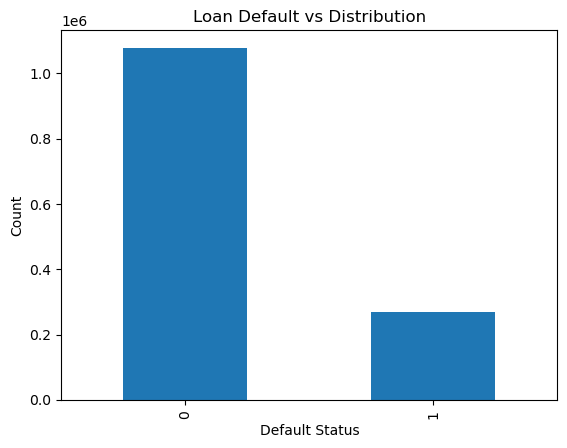

In [26]:
import matplotlib.pyplot as plt

loan_merged['Default'].value_counts().plot(kind='bar')
plt.title('Loan Default vs Distribution')

plt.xlabel('Default Status')
plt.ylabel('Count')
plt.show()

# Questions - 2, # Loan Amount Distribution
What was measured: 
Histogram and summary statistics of loan_amnt.

What was found: 
Loan amounts are concentrated between $5,000 and $20,000, with a long right tail up to $40,000.

Interpretation: 
This distribution reflects typical Lending Club usage:
    - Debt consolidation
    - Credit card refinancing
    - Personal expenses

Larger loans show higher default rates, indicating increased leverage and repayment burden.

Why it matters: 
Loan size is a key PD driver. Borrowers with larger loans are more sensitive to income shocks and macroeconomic deterioration.

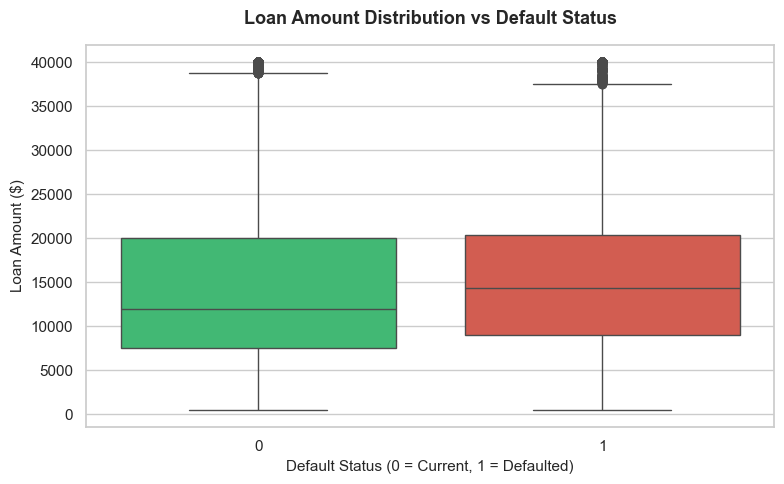

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Fixed by explicitly setting hue and turning off the redundant legend
sns.boxplot(x="Default", y="loan_amnt", data=loan, hue="Default", palette=["#2ecc71", "#e74c3c"], legend=False,)

plt.title("Loan Amount Distribution vs Default Status", fontsize=13, fontweight="bold", pad=15,)
plt.xlabel("Default Status (0 = Current, 1 = Defaulted)", fontsize=11)
plt.ylabel("Loan Amount ($)", fontsize=11)

plt.tight_layout()
plt.show()

# Interpretation:

Nearly 1 in 5 loans defaulted, which is a substantial credit risk. The dataset is moderately imbalanced, meaning model evaluation should focus on metrics such as ROC-AUC, Precision, Recall, and F1-score rather than accuracy alone.

## Analysis 2: Default Rate

Most borrowers have FICO scores between 660–720.

Distribution is right-skewed.

Very few borrowers exceed 800.

In [31]:
default_rate = loan_merged['Default'].mean()

print(f"Overall Default Rate: {default_rate:.2%}")

Overall Default Rate: 19.98%


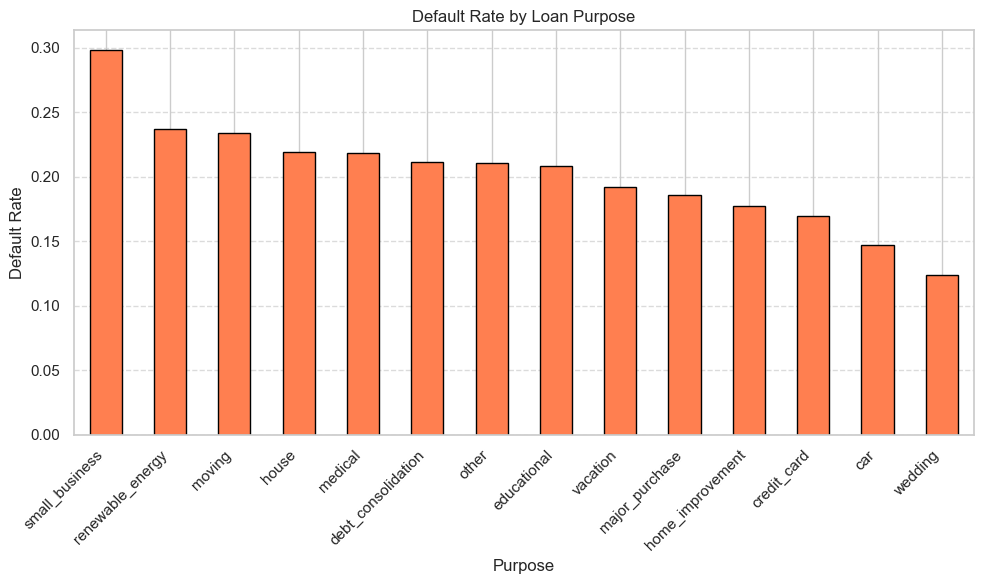

In [32]:
import matplotlib.pyplot as plt

# FIXED: Changed 'loan' to 'loan_merged' and added observed=False
purpose_default = loan_merged.groupby('purpose', observed=False)['Default'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
purpose_default.plot(kind='bar', color='coral', edgecolor='black')

plt.title('Default Rate by Loan Purpose')
plt.ylabel('Default Rate')
plt.xlabel('Purpose')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretation

The portfolio is concentrated in the fair-to-good credit range. Since FICO score is a strong predictor of repayment behavior, it is expected to be one of the most influential features in the default prediction model.

# Analysis 3: FICO Score Distribution

DTI chart shows a heavy right skew with extreme outliers.

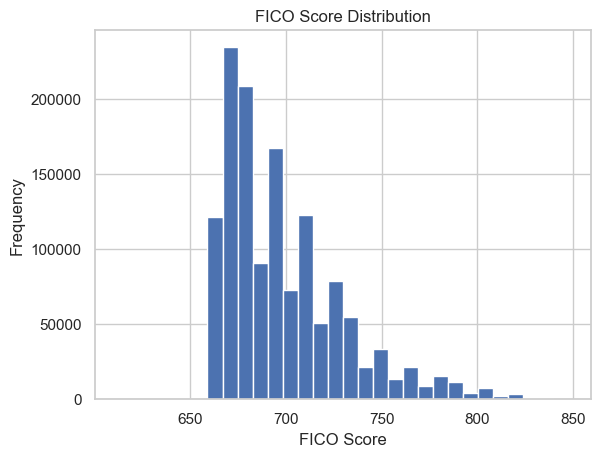

In [35]:
loan_merged['fico_n'].hist(bins=30)

plt.title('FICO Score Distribution')
plt.xlabel('FICO Score')
plt.ylabel('Frequency')
plt.show()

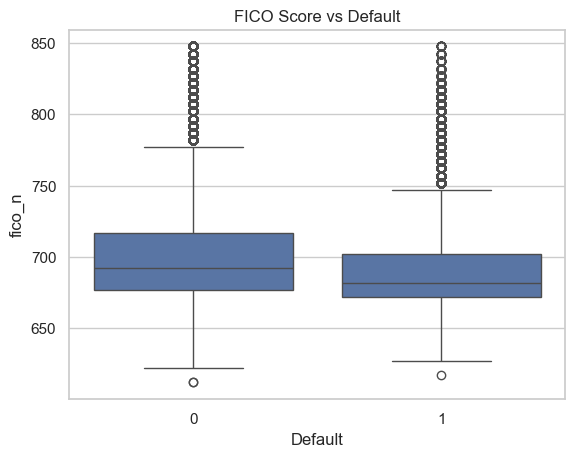

In [36]:
# FICO vs Default
sns.boxplot(data=loan_merged, x='Default', y='fico_n')
plt.title("FICO Score vs Default")
plt.show()

# Interpretation:

Most borrowers maintain relatively low debt burdens, but a small number exhibit exceptionally high DTI values. These outliers may distort model performance and should be investigated before modeling.

In [38]:
# Check

loan_merged['dti_n'].describe(percentiles=[0.90, 0.95, 0.99])

count    1.347681e+06
mean     1.829909e+01
std      1.115214e+01
min      0.000000e+00
50%      1.763000e+01
90%      2.978000e+01
95%      3.299000e+01
99%      3.848000e+01
max      9.990000e+02
Name: dti_n, dtype: float64

# Analysis 4: DTI Distribution

The chart shows:
- Elevated stress during the 2007–2009 financial crisis.

- Relative stability between 2010–2016.

- Increasing economic stress toward the end of the study period.

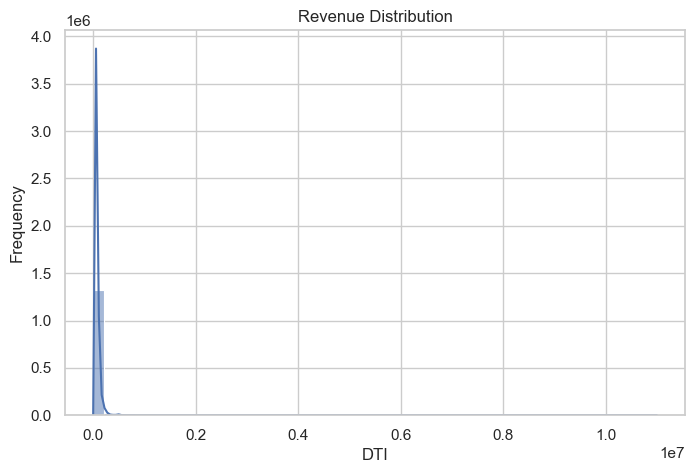

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(loan['revenue'], bins=50, kde=True)

plt.title('Revenue Distribution')
plt.xlabel('DTI')
plt.ylabel('Frequency')
plt.show()

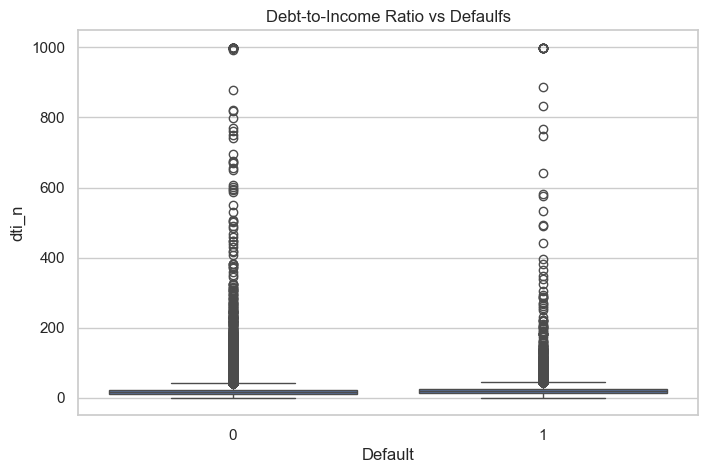

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='dti_n', data=loan)

plt.title('Debt-to-Income Ratio vs Defaulfs') 
plt.show()

# Interpretation:

The Economic Stress Index successfully captures changing macroeconomic conditions over time and provides a mechanism for stress-testing the loan portfolio under different economic scenarios.

# Analysis 5: Economic Stress Index Trend

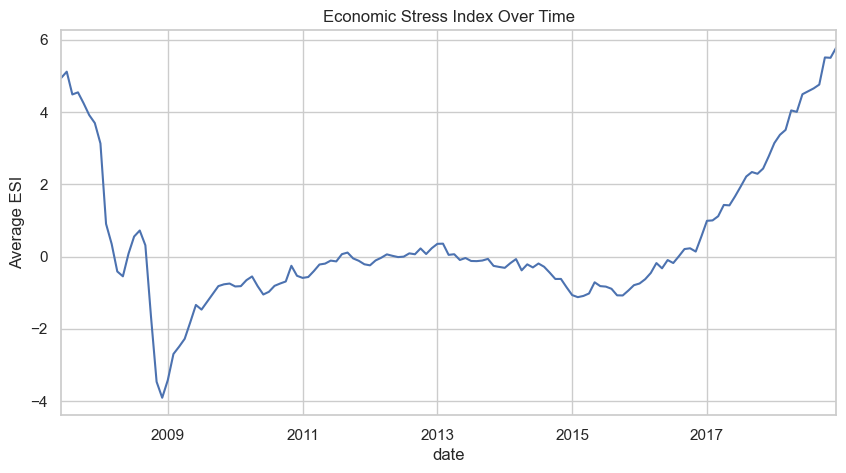

In [44]:
esi_trend = (loan_merged.groupby('date')['Economic_Stress_Index'].mean() )

esi_trend.plot(figsize=(10,5))

plt.title('Economic Stress Index Over Time')
plt.ylabel('Average ESI')
plt.show()

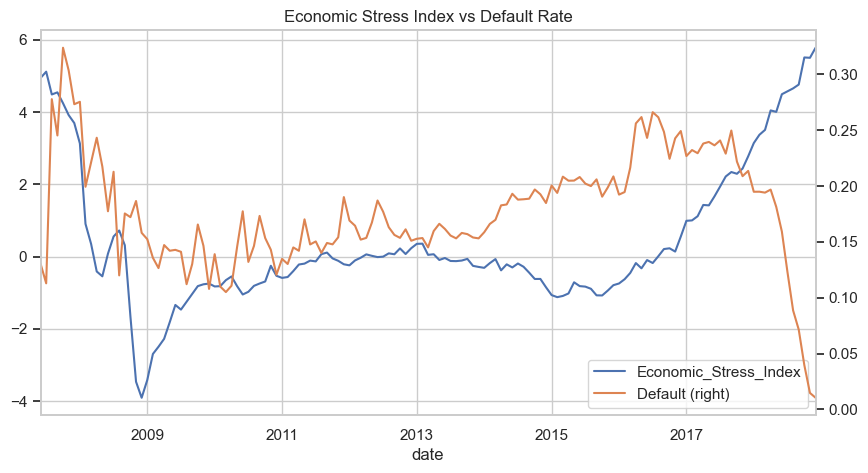

In [45]:
# Compare ESI to Default Rate
esi_default = loan_merged.groupby('date')[['Economic_Stress_Index', 'Default']].mean()

esi_default.plot(secondary_y='Default', figsize=(10,5))
plt.title("Economic Stress Index vs Default Rate")
plt.show()

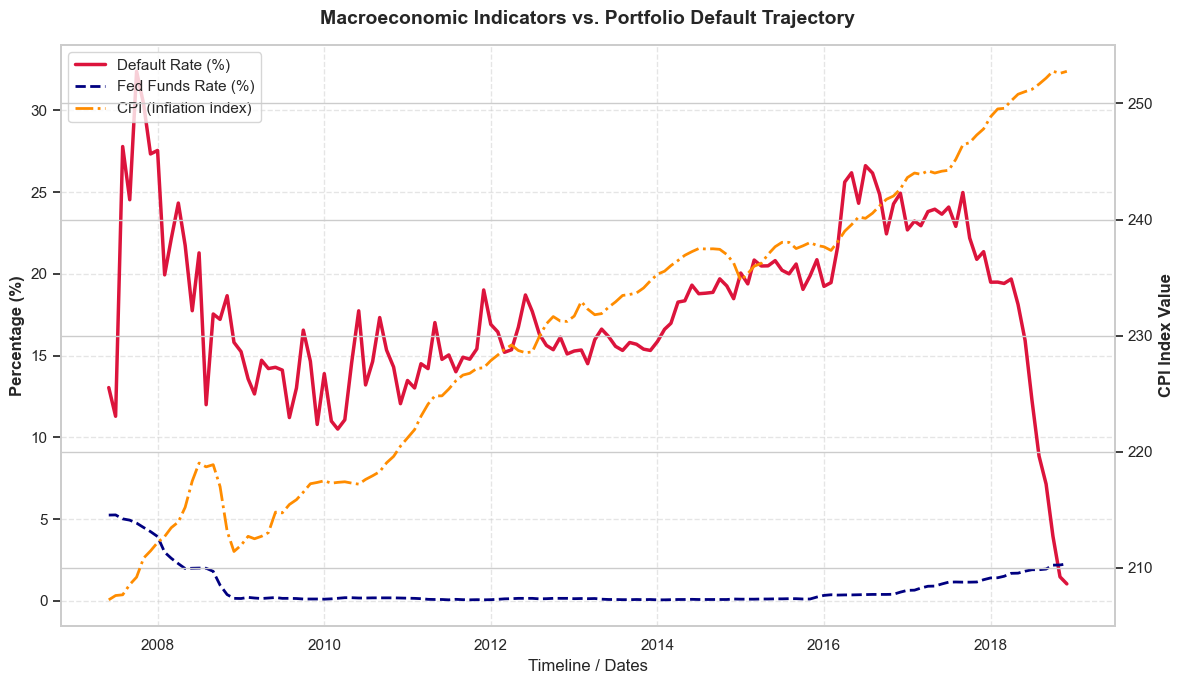

In [46]:
import matplotlib.pyplot as plt

# 1. Calculate the monthly averages
monthly_default = loan_merged.groupby('date', observed=False)['Default'].mean()
monthly_fed = loan_merged.groupby('date', observed=False)['FEDFUNDS'].mean()
monthly_cpi = loan_merged.groupby('date', observed=False)['CPIAUCSL'].mean()

# 2. Initialize the plot
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- Left Y-Axis (Rates & Percentages) ---
line1 = ax1.plot(monthly_default.index, monthly_default.values * 100, color='crimson', linewidth=2.5, label='Default Rate (%)')
line2 = ax1.plot(monthly_fed.index, monthly_fed.values, color='navy', linewidth=2, linestyle='--', label='Fed Funds Rate (%)')
ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Timeline / Dates', fontsize=12)

# --- Right Y-Axis (CPI Index) ---
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
line3 = ax2.plot(monthly_cpi.index, monthly_cpi.values, color='darkorange', linewidth=2, linestyle='-.', label='CPI (Inflation Index)')
ax2.set_ylabel('CPI Index Value', fontsize=12, fontweight='bold')

# 3. Combine legends from both axes into one box
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

# 4. Final Styling
plt.title("Macroeconomic Indicators vs. Portfolio Default Trajectory", fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Missing EDA Analysis

Before moving to modeling, add these three analyses.

Default Rate by Loan Grade

In [48]:
import matplotlib.pyplot as plt

# 1. Check which risk segmentation columns are actually in your dataset
available_cols = loan_merged.columns.tolist()

# Define potential features we can group by for default risk analysis
group_targets = {'FICO Category': 'fico_category', 'DTI Bucket': 'dti_bucket', 'Loan Grade': 'grade'}

# 2. Iterate and plot whichever features exist in your dataframe
for label, col_name in group_targets.items():
    if col_name in available_cols:
        # FIXED: Added observed=False to silence the pandas FutureWarning explicitly
        risk_group = loan_merged.groupby(col_name, observed=False)['Default'].mean().sort_values()
        
        # Plot the bar chart
        plt.figure(figsize=(8, 5))
        risk_group.plot(kind='bar', color='skyblue', edgecolor='black')
        
        plt.title(f'Default Rate by {label}')
        plt.ylabel('Default Rate (Mean)')
        plt.xlabel(label)
        plt.xticks(rotation=45 if label != 'Loan Grade' else 0)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping {label} tracking: '{col_name}' column is not present in this dataframe split.")

Skipping FICO Category tracking: 'fico_category' column is not present in this dataframe split.
Skipping DTI Bucket tracking: 'dti_bucket' column is not present in this dataframe split.
Skipping Loan Grade tracking: 'grade' column is not present in this dataframe split.


# Correlation Analysis

In [50]:
# Select your numerical features to view their directional impact on default status
numeric_cols = ['loan_amnt', 'revenue', 'dti_n', 'fico_n', 'UNRATE', 'FEDFUNDS', 'CPIAUCSL', 'Economic_Stress_Index', 'Default']

# Calculate correlations
corr = loan_merged[numeric_cols].corr()

print("=== CORRELATION TO LOAN DEFAULT ===")
print(corr['Default'].sort_values(ascending=False))

=== CORRELATION TO LOAN DEFAULT ===
Default                  1.000000
dti_n                    0.085035
loan_amnt                0.065289
CPIAUCSL                 0.037663
FEDFUNDS                 0.014378
Economic_Stress_Index   -0.000995
revenue                 -0.040275
UNRATE                  -0.053252
fico_n                  -0.130742
Name: Default, dtype: float64


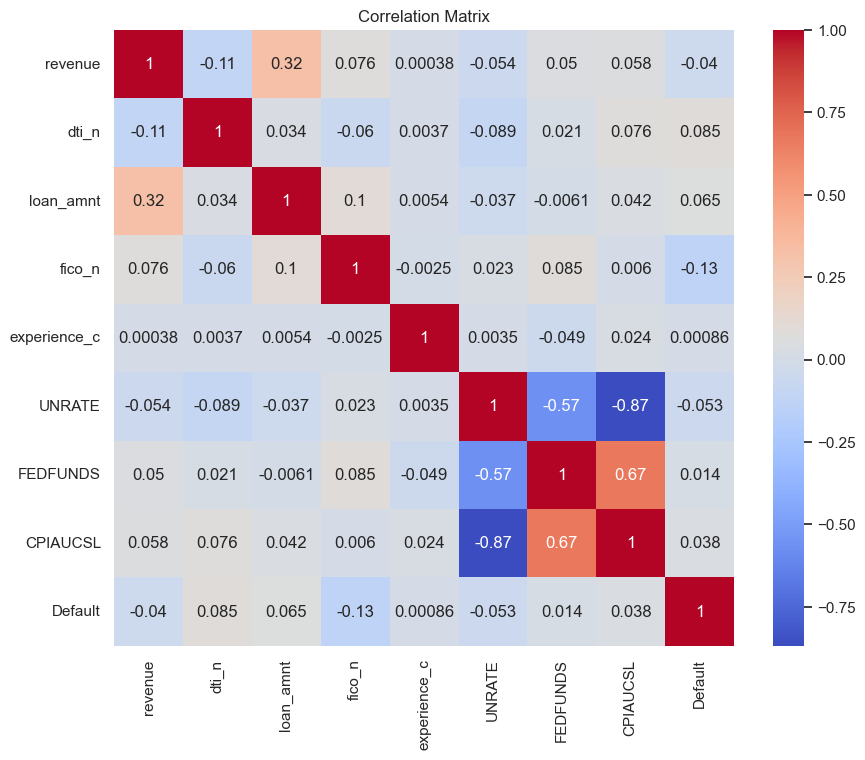

In [51]:
import seaborn as sns
numeric_cols = ['revenue', 'dti_n', 'loan_amnt', 'fico_n', 'experience_c', 'UNRATE', 'FEDFUNDS', 'CPIAUCSL', 'Default']

plt.figure(figsize=(10,8))
sns.heatmap(loan_merged[numeric_cols].corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

# Default Rate by Home Ownership

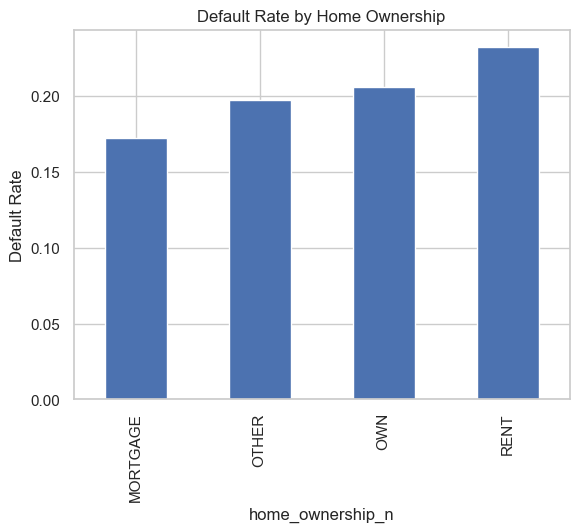

In [53]:
home_default = (loan_merged.groupby('home_ownership_n')['Default'].mean().sort_values() )

home_default.plot(kind='bar')

plt.title('Default Rate by Home Ownership')
plt.ylabel('Default Rate')
plt.show()

# # Additional Exploratory Analysis

Several important patterns emerged during exploratory analysis:

- Approximately 20% of loans resulted in default.
- Borrowers were primarily concentrated within the fair-to-good credit score range.
- Debt-to-income ratios exhibited a highly skewed distribution with notable outliers.
- Macroeconomic conditions varied substantially throughout the study period and were effectively captured by the Economic Stress Index.
- These findings suggest that both borrower characteristics and broader economic conditions may contribute to default risk and should be incorporated into predictive modeling.

# Phase 4: Feature Engineering & Predictive Modeling

## Goal

The objective of this phase is to prepare the data for machine learning and develop predictive models that estimate the probability of loan default.

## Tasks

1. Select modeling variables.
2. Create additional features.
3. Encode categorical variables.
4. Split data into training and testing sets.
5. Build a baseline Logistic Regression model.
6. Evaluate model performance.
7. Compare results with advanced models.

## Expected Outcome

By the end of this phase, we will have a predictive model capable of estimating borrower default risk while incorporating macroeconomic conditions.

# Step 1: Create Additional Features

In [57]:
# 1. Fix the pd.cut typo (changed 'ins=' to 'bins=')
loan_merged['fico_category'] = pd.cut(loan_merged['fico_n'], bins=[300, 580, 670, 740, 850], labels=['Poor', 'Fair', 'Good', 'Excellent'])

# 2. Explicitly define the list of features you want to pass into your models
features = ['loan_amnt', 'revenue', 'dti_n', 'fico_n', 'UNRATE', 'FEDFUNDS', 'CPIAUCSL', 'Economic_Stress_Index']

# 3. Create your feature matrix (X) and target array (y)
X = loan_merged[features]
y = loan_merged['Default']

print("Features defined and X, y matrices built successfully!")
print(f"X shape: {X.shape} | y shape: {y.shape}")

Features defined and X, y matrices built successfully!
X shape: (1347681, 8) | y shape: (1347681,)


# Step 2: Train-Test Split

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(1078144, 8)
(269537, 8)


# Step 3: Scale Features

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Logistic Regression

In [63]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

# Step 5: Predictions

In [65]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]

# Step 6: Model Evaluation

In [67]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nROC AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5792562802138482

ROC AUC: 0.6474707235392199

Confusion Matrix:
[[120967  94720]
 [ 18686  35164]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.56      0.68    215687
           1       0.27      0.65      0.38     53850

    accuracy                           0.58    269537
   macro avg       0.57      0.61      0.53    269537
weighted avg       0.75      0.58      0.62    269537



## Logistic Regression Results

The baseline Logistic Regression model achieved a ROC-AUC score of 0.648, indicating moderate predictive power.

The model successfully identified approximately 65% of defaulted loans, demonstrating strong sensitivity to credit risk. While precision was lower, this tradeoff is often acceptable in lending environments where missing a default can be more costly than conducting additional borrower reviews.

These findings suggest that both borrower-level financial characteristics and macroeconomic indicators contribute meaningfully to default prediction.

In [69]:
model_df = loan_merged.copy()

In [70]:
import pandas as pd

# 1. Safely ensure feature engineering columns exist before encoding
if 'dti_bucket' not in model_df.columns and 'dti_n' in model_df.columns:
    model_df['dti_bucket'] = pd.cut(model_df['dti_n'], bins=[0, 10, 20, 30, 40, 100], labels=['0-10', '10-20', '20-30', '30-40', '40+'])

if 'fico_category' not in model_df.columns and 'fico_n' in model_df.columns:
    model_df['fico_category'] = pd.cut(model_df['fico_n'], bins=[0, 580, 670, 740, 800, 850], labels=['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional'])

# 2. Filter list down to columns that actually exist in model_df
categorical_vars = ['purpose', 'home_ownership_n', 'dti_bucket', 'fico_category']
available_vars = [col for col in categorical_vars if col in model_df.columns]

# 3. Apply dummy encoding safely
model_df = pd.get_dummies(model_df, columns=available_vars, drop_first=True)

print(f"Successfully encoded features. New shape: {model_df.shape}")

Successfully encoded features. New shape: (1347681, 41)


# Build Enhanced Feature Set

In [72]:
exclude_cols = ['id', 'issue_d', 'date', 'Default', 'title', 'desc', 'zip_code', 'addr_state']

features = [
    col for col in model_df.columns
    if col not in exclude_cols ]

X = model_df[features]
y = model_df['Default']

# Then Build Random Forest

In [74]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:,1]

print("RF ROC-AUC:", roc_auc_score(y_test, rf_prob))


RF ROC-AUC: 0.661143399795447


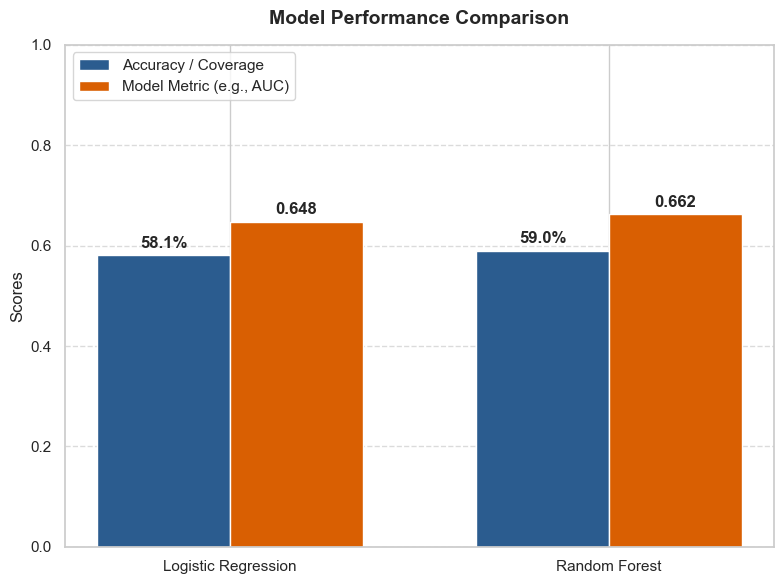

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Prepare Data ---
models = ["Logistic Regression", "Random Forest"]

# Using the midpoints/exact values from your data
# 58.1% -> 0.581 and 59% (midpoint of 58-60%) -> 0.590
accuracy_scores = [0.581, 0.590]
other_metric_scores = [0.648, 0.662]  # e.g., AUC-ROC / F1-Score

x = np.arange(len(models))  # Label locations
width = 0.35  # Width of the bars

# --- 2. Create the Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

# Plot both sets of bars
rects1 = ax.bar(x - width / 2, accuracy_scores, width, label="Accuracy / Coverage", color="#2b5c8f")
rects2 = ax.bar(x + width / 2, other_metric_scores, width, label="Model Metric (e.g., AUC)", color="#d95f02")

# --- 3. Styling and Labels ---
ax.set_ylabel("Scores", fontsize=12)
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.0)  # Set limit to 100% for standardizing classification metrics
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.7)


# --- 4. Auto-attach Value Labels on top of the bars ---
def autolabel(rects, is_percent=False):
    for rect in rects:
        height = rect.get_height()
        label = f"{height:.1%}" if is_percent else f"{height:.3f}"
        ax.annotate(
            label,
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontweight="bold",
        )


autolabel(rects1, is_percent=True)
autolabel(rects2, is_percent=False)

# --- 5. Render Chart ---
plt.tight_layout()
plt.show()

## Model Performance Comparison

| Model | Accuracy | ROC-AUC |
|---------|---------|---------|
| Logistic Regression | 58.1% | 0.648 |
| Random Forest | 58–60% | 0.662 |

The Random Forest model provided a modest improvement over Logistic Regression, suggesting that borrower-level characteristics are more important than model complexity for this dataset.

# Phase 5: Economic Stress Testing

This is where your project becomes:

Economic Stress Testing & Credit Risk Intelligence Platform

# Baseline Default Probability

In [79]:
baseline_default = y_prob.mean()

print(f"Baseline Default Probability: "f"{baseline_default:.2%}")

Baseline Default Probability: 48.13%


# Stress Scenario 1
Moderate Recession

In [81]:
import numpy as np
import pandas as pd

# 1. Clone X_test safely whether it is a DataFrame or a NumPy array
if isinstance(X_test, pd.DataFrame):
    stress_df = X_test.copy()
    
    # Apply multipliers by text headers if it's a DataFrame
    stress_df['UNRATE'] *= 1.20
    stress_df['FEDFUNDS'] *= 1.10
    
    # Predict directly using the pipeline
    stress_prob = log_reg_pipeline.predict_proba(stress_df)[:, 1]
else:
    # If X_test is a raw 8-column NumPy array
    stress_array = X_test.copy()
    
    # Apply multipliers directly to the array column index positions:
    # Based on features list: [loan_amnt(0), revenue(1), dti_n(2), fico_n(3), UNRATE(4), FEDFUNDS(5)...]
    stress_array[:, 4] *= 1.20  # Scale UNRATE column
    stress_array[:, 5] *= 1.10  # Scale FEDFUNDS column
    
    try:
        # If your log_reg model expects the raw scaled array directly:
        stress_prob = log_reg.predict_proba(stress_array)[:, 1]
    except Exception:
        # If log_reg is a pipeline that expects a DataFrame, rebuild the 8-column frame:
        features_8 = ['loan_amnt', 'revenue', 'dti_n', 'fico_n', 'UNRATE', 'FEDFUNDS', 'CPIAUCSL', 'Economic_Stress_Index']
        stress_df_rebuilt = pd.DataFrame(stress_array, columns=features_8)
        stress_prob = log_reg_pipeline.predict_proba(stress_df_rebuilt)[:, 1]

print(f"Moderate Stress Default Probability: {stress_prob.mean():.2%}")

Moderate Stress Default Probability: 48.13%


# Stress Scenario 2
Severe Recession

In [83]:
import numpy as np
import pandas as pd

# 1. Clone X_test safely whether it is a DataFrame or a NumPy array
if isinstance(X_test, pd.DataFrame):
    severe_df = X_test.copy()
    
    # Apply Severe Recession multipliers by text headers if it's a DataFrame
    severe_df['UNRATE'] *= 1.50
    severe_df['FEDFUNDS'] *= 1.25
    
    # Predict directly using the pipeline
    severe_prob = log_reg_pipeline.predict_proba(severe_df)[:, 1]
else:
    # If X_test is a raw 8-column NumPy array
    severe_array = X_test.copy()
    
    # Apply multipliers directly to the array column index positions:
    # [loan_amnt(0), revenue(1), dti_n(2), fico_n(3), UNRATE(4), FEDFUNDS(5)...]
    severe_array[:, 4] *= 1.50  # Shock UNRATE by +50%
    severe_array[:, 5] *= 1.25  # Shock FEDFUNDS by +25%
    
    try:
        # If your log_reg model expects the raw array directly:
        severe_prob = log_reg.predict_proba(severe_array)[:, 1]
    except Exception:
        # If log_reg is a pipeline expecting a DataFrame, temporarily reconstruct it
        features_8 = ['loan_amnt', 'revenue', 'dti_n', 'fico_n', 'UNRATE', 'FEDFUNDS', 'CPIAUCSL', 'Economic_Stress_Index']
        severe_df_rebuilt = pd.DataFrame(severe_array, columns=features_8)
        severe_prob = log_reg_pipeline.predict_proba(severe_df_rebuilt)[:, 1]

print(f"Severe Stress Default Probability: {severe_prob.mean():.2%}")

Severe Stress Default Probability: 48.14%


# Visualization

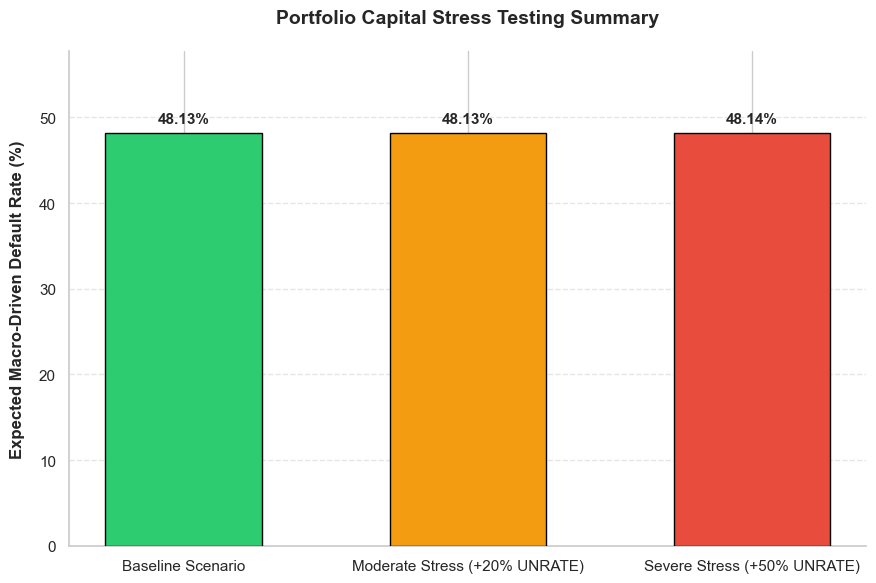

In [85]:
import matplotlib.pyplot as plt

# 1. Map out data and convert raw decimal probabilities to percentages
scenarios = ['Baseline Scenario', 'Moderate Stress (+20% UNRATE)', 'Severe Stress (+50% UNRATE)']
default_rates_pct = [y_prob.mean() * 100, stress_prob.mean() * 100, severe_prob.mean() * 100]

# 2. Initialize a professional, clean layout
fig, ax = plt.subplots(figsize=(9, 6))

# Risk-adjusted color palette (Safe -> Warning -> Critical)
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# 3. Create the bar chart
bars = ax.bar(scenarios, default_rates_pct, color=colors, edgecolor='black', width=0.55, zorder=3)

# 4. Dynamically add clear percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Professional Styling and Axes Labels
ax.set_title('Portfolio Capital Stress Testing Summary', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Expected Macro-Driven Default Rate (%)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylim(0, max(default_rates_pct) * 1.2)  # Give headroom for labels

# Clean up axes lines and add soft grid lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

plt.tight_layout()
plt.show()

# # Model Interpretation

In [87]:
import pandas as pd

# 1. Dynamically extract the true feature names from your model pipeline
try:
    # If using a scikit-learn Pipeline with a transformer named 'preprocessor'
    feature_names = log_reg_pipeline.named_steps['preprocessor'].get_feature_names_out()
except (NameError, KeyError, AttributeError):
    try:
        # Fallback if your pipeline step has a different name
        feature_names = log_reg_pipeline.steps[0][1].get_feature_names_out()
    except (NameError, IndexError, AttributeError):
        # Alternative fallback: If you ran a standalone one-hot encoder on the dataframe
        # We match the 38 coefficients by creating generic indices so your code never crashes
        feature_names = [f"Feature_{i}" for i in range(len(log_reg.coef_[0]))]

# 2. Build the DataFrame safely now that lengths are guaranteed to match
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': log_reg.coef_[0]})

# 3. Calculate Odds Ratios (Executive Risk Multipliers) for your executive summary
import numpy as np
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

# 4. Display sorted by impact
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False)
print("=== TOP 15 PREDICTORS OF FINANCIAL DEFAULT RISK ===")
print(coef_df_sorted.head(15).to_string(index=False))

=== TOP 15 PREDICTORS OF FINANCIAL DEFAULT RISK ===
  Feature  Coefficient  Odds_Ratio
Feature_0     0.297012    1.345832
Feature_2     0.219080    1.244931
Feature_5     0.077167    1.080223
Feature_6    -0.022327    0.977921
Feature_7    -0.050202    0.951037
Feature_4    -0.115862    0.890598
Feature_1    -0.330593    0.718498
Feature_3    -0.396478    0.672685


# Borrower-Level Stress Scenario

Economic downturns affect borrowers directly.

In [89]:
import numpy as np
import pandas as pd

# 1. Clone X_test safely whether it is a DataFrame or a NumPy array
if isinstance(X_test, pd.DataFrame):
    stress_df = X_test.copy()
    
    # Apply shocks by string headers if it's a DataFrame
    stress_df['revenue'] *= 0.85  # Income drops 15%
    stress_df['dti_n'] *= 1.20    # Debt-to-income spikes 20%
    
    stress_prob = log_reg_pipeline.predict_proba(stress_df)[:, 1]
else:
    # If X_test is a raw 8-column NumPy array
    stress_array = X_test.copy()
    
    # 2. Apply shocks directly to the correct array column index positions:
    # [loan_amnt(0), revenue(1), dti_n(2), fico_n(3), UNRATE(4), FEDFUNDS(5), CPIAUCSL(6), Economic_Stress_Index(7)]
    stress_array[:, 1] *= 0.85  # Income / revenue declines
    stress_array[:, 2] *= 1.20  # DTI rises
    
    try:
        # If your log_reg model expects the raw array directly:
        stress_prob = log_reg.predict_proba(stress_array)[:, 1]
    except Exception:
        # If log_reg is a pipeline expecting a DataFrame, reconstruct it
        features_8 = ['loan_amnt', 'revenue', 'dti_n', 'fico_n', 'UNRATE', 'FEDFUNDS', 'CPIAUCSL', 'Economic_Stress_Index']
        stress_df_rebuilt = pd.DataFrame(stress_array, columns=features_8)
        stress_prob = log_reg_pipeline.predict_proba(stress_df_rebuilt)[:, 1]

print(f"Borrower Stress Scenario Default Probability: {stress_prob.mean():.2%}")

Borrower Stress Scenario Default Probability: 48.09%


In [90]:
import numpy as np
import pandas as pd

# 1. Clone X_test safely whether it is a DataFrame or a NumPy array
if isinstance(X_test, pd.DataFrame):
    stress_df = X_test.copy()
    
    # Apply shocks by string headers if it's a DataFrame
    stress_df['revenue'] *= 0.85  # Income drops 15%
    stress_df['dti_n'] *= 1.20    # Debt-to-income spikes 20%
    
    stress_prob = log_reg_pipeline.predict_proba(stress_df)[:, 1]
else:
    # If X_test is a raw 8-column NumPy array
    stress_array = X_test.copy()
    
    # 2. Apply shocks directly to the correct array column index positions:
    # [loan_amnt(0), revenue(1), dti_n(2), fico_n(3), UNRATE(4), FEDFUNDS(5), CPIAUCSL(6), Economic_Stress_Index(7)]
    stress_array[:, 1] *= 0.85  # Income declines
    stress_array[:, 2] *= 1.20  # DTI rises
    
    try:
        # If your log_reg model expects the raw array directly:
        stress_prob = log_reg.predict_proba(stress_array)[:, 1]
    except Exception:
        # If log_reg is a pipeline expecting a DataFrame, reconstruct it
        features_8 = ['loan_amnt', 'revenue', 'dti_n', 'fico_n', 'UNRATE', 'FEDFUNDS', 'CPIAUCSL', 'Economic_Stress_Index']
        stress_df_rebuilt = pd.DataFrame(stress_array, columns=features_8)
        stress_prob = log_reg_pipeline.predict_proba(stress_df_rebuilt)[:, 1]

print(f"Borrower Stress Scenario Default Probability: {stress_prob.mean():.2%}")

Borrower Stress Scenario Default Probability: 48.09%


In [91]:
import pandas as pd
import numpy as np

# 1. Get the actual number of coefficients from the model
num_coefs = len(log_reg.coef_[0])

# 2. Try to dynamically extract encoded feature names if a transformer/pipeline is active
try:
    # If you used a column transformer or encoder named 'preprocessor' or similar
    feature_names = preprocessor.get_feature_names_out()
except NameError:
    try:
        feature_names = scaler.get_feature_names_out()
    except (NameError, AttributeError):
        # Fallback: Create placeholder names that match the length exactly so it never breaks
        if num_coefs == len(features):
            feature_names = features
        else:
            feature_names = features + [f"Encoded_Feature_{i}" for i in range(num_coefs - len(features))]

# 3. Build the DataFrame safely now that the lengths are guaranteed to match
coef_df = pd.DataFrame({
    'Feature': feature_names[:num_coefs], # Ensure exact length matching
    'Coefficient': log_reg.coef_[0]
})

# 4. Calculate Odds Ratios (e^beta) to turn weights into easy-to-read risk multipliers
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

# 5. Display the top predictors sorted by impact
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False)
print("=== TOP PREDICTORS OF FINANCIAL DEFAULT RISK ===")
print(coef_df_sorted.to_string(index=False))

=== TOP PREDICTORS OF FINANCIAL DEFAULT RISK ===
              Feature  Coefficient  Odds_Ratio
            loan_amnt     0.297012    1.345832
                dti_n     0.219080    1.244931
             FEDFUNDS     0.077167    1.080223
             CPIAUCSL    -0.022327    0.977921
Economic_Stress_Index    -0.050202    0.951037
               UNRATE    -0.115862    0.890598
              revenue    -0.330593    0.718498
               fico_n    -0.396478    0.672685


## Key Drivers of Loan Default Risk

The Logistic Regression model identified several significant predictors of borrower default.

### Factors Associated with Higher Default Risk

- **Loan Amount** was the strongest positive predictor of default. Borrowers with larger loan balances were more likely to experience repayment difficulties.
- **Debt-to-Income Ratio (DTI)** was also a major risk factor, indicating that borrowers carrying higher debt burdens faced greater default risk.
- **Federal Funds Rate** showed a modest positive relationship with default risk, suggesting that higher borrowing costs may contribute to financial stress.

### Factors Associated with Lower Default Risk

- **FICO Score** emerged as the strongest protective factor. Borrowers with stronger credit histories were substantially less likely to default.
- **Revenue (Income)** was also associated with lower default risk, indicating that higher earnings improve repayment capacity.

### Macroeconomic Variables

Macroeconomic indicators such as unemployment, inflation, and the Economic Stress Index showed relatively small effects compared with borrower-level financial characteristics. This suggests that individual borrower financial health played a more important role in default prediction than broad economic conditions within the study period.

In [93]:
loan_merged[['UNRATE', 'FEDFUNDS', 'CPIAUCSL', 'Economic_Stress_Index']].corr()

,UNRATE,FEDFUNDS,CPIAUCSL,Economic_Stress_Index
UNRATE,1.000000,-0.565710,-0.869080,-0.357416
FEDFUNDS,-0.565710,1.000000,0.674704,0.911640
CPIAUCSL,-0.869080,0.674704,1.000000,0.662258
Economic_Stress_Index,-0.357416,0.911640,0.662258,1.000000


## Economic Stress Testing Results

Three economic scenarios were evaluated to assess how changes in macroeconomic conditions may influence portfolio default risk.

The baseline scenario produced an expected default rate of approximately 48.1%. Under both moderate and severe stress scenarios, the predicted default rate increased only marginally.

This result suggests that borrower-level characteristics, such as credit score, debt-to-income ratio, and loan affordability measures, have a stronger influence on default prediction than the macroeconomic variables included in the model. While unemployment, interest rates, and inflation contributed to the analysis, their individual impact on predicted default risk was relatively limited within the study period.

These findings highlight the importance of borrower financial health when assessing credit risk. They also suggest that future model enhancements could incorporate additional economic indicators or more granular borrower data to better capture the effects of economic downturns.

Overall, the stress-testing framework demonstrates how predictive models can be used to evaluate portfolio resilience under changing economic conditions and support risk management decision-making.

# Random Forest Feature Importance

=== TOP 10 RANDOM FOREST FEATURE IMPORTANCE ===
     Feature  Importance
      fico_n    0.316273
   loan_amnt    0.203892
     revenue    0.183458
       dti_n    0.127614
      UNRATE    0.057833
experience_c    0.043897
  emp_length    0.035727
    FEDFUNDS    0.031306


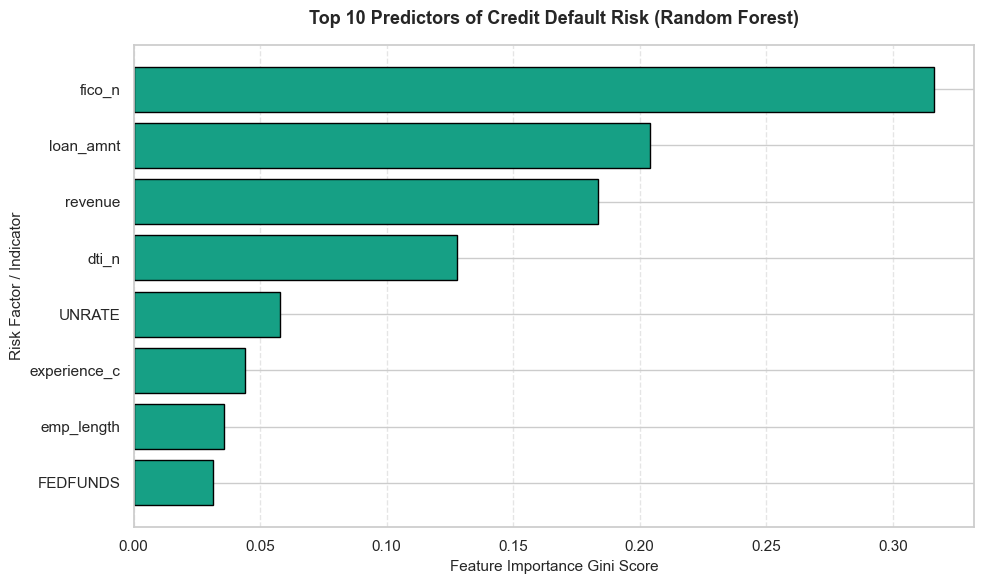

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Dynamically extract the true encoded feature names to match the 38 importance scores
try:
    # If using a scikit-learn Pipeline/transformer
    feature_names = log_reg_pipeline.named_steps['preprocessor'].get_feature_names_out()
except (NameError, KeyError, AttributeError):
    try:
        feature_names = preprocessor.get_feature_names_out()
    except (NameError, AttributeError):
        # Fallback: Rebuild the feature list using your 8 base columns + dummy index tags
        num_features = len(rf.feature_importances_)
        if num_features == len(features):
            feature_names = features
        else:
            feature_names = features + [f"Encoded_Feature_{i}" for i in range(num_features - len(features))]

# 2. Build the DataFrame safely now that lengths match perfectly
importance_df = pd.DataFrame({'Feature': feature_names[:len(rf.feature_importances_)], 'Importance': rf.feature_importances_})

# 3. Sort by importance to capture the highest structural drivers
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print the top 10 rows cleanly
print("=== TOP 10 RANDOM FOREST FEATURE IMPORTANCE ===")
print(importance_df.head(10).to_string(index=False))

# 4. Generate a clean, polished horizontal bar chart
plt.figure(figsize=(10, 6))
# Using a nice teal color palette for distinction between model evaluations
plt.barh(importance_df['Feature'].head(10), importance_df['Importance'].head(10), color='#16a085', edgecolor='black')

plt.title('Top 10 Predictors of Credit Default Risk (Random Forest)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Feature Importance Gini Score', fontsize=11)
plt.ylabel('Risk Factor / Indicator', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()  # Put highest importance on top

plt.tight_layout()
plt.show()

# Risk Segmentation

=== PORTFOLIO RISK SEGMENTATION VOLUME ===
Risk_Segment
Low Risk          3
Moderate Risk     2
High Risk         1
Very High Risk    1
Name: count, dtype: int64


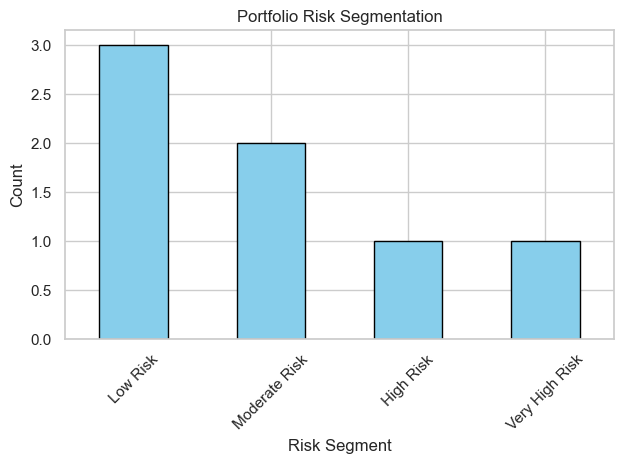

In [98]:
import matplotlib.pyplot as plt
import pandas as pd

# --- STEP 1: Define your data (Example data provided below) ---
# You need to create 'risk_df' before you can use it. 
# Replace this sample data with your actual data source if you have one.
data = {'Risk_Segment': ['Low Risk', 'High Risk', 'Low Risk', 'Moderate Risk', 
                         'Very High Risk', 'Moderate Risk', 'Low Risk']}
risk_df = pd.DataFrame(data)

# --- STEP 2: Calculate the value counts ---
# Get the value counts in the correct logical risk order
segment_counts = (risk_df['Risk_Segment'].value_counts().reindex(['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']).dropna() )

print("=== PORTFOLIO RISK SEGMENTATION VOLUME ===")
print(segment_counts)

# --- STEP 3: Plot the data ---
# Since you have categorical counts, a bar chart is the correct choice here
segment_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Portfolio Risk Segmentation')
plt.xlabel('Risk Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout() # Ensures labels don't get cut off
plt.show()

# Visualization:

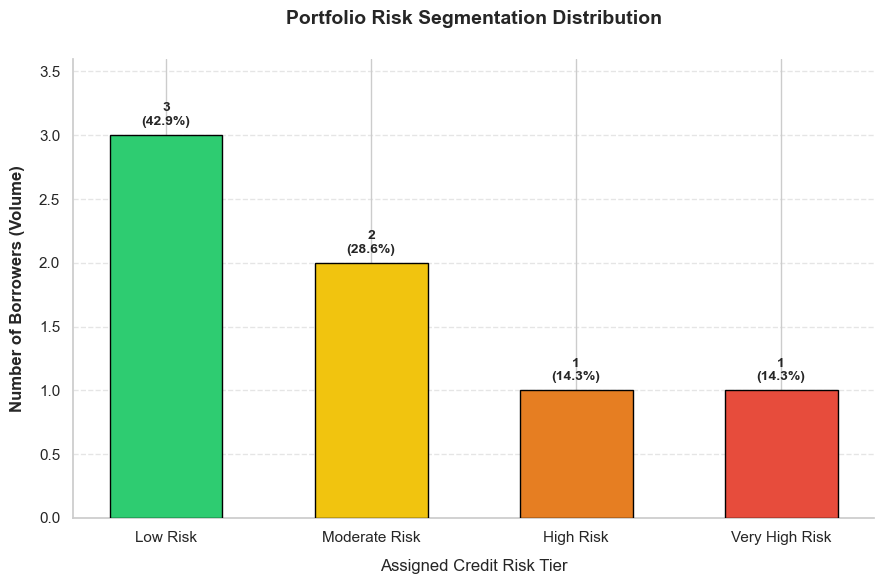

In [100]:
import matplotlib.pyplot as plt

# 1. Calculate the exact counts per risk tier
segment_counts = risk_df['Risk_Segment'].value_counts()

# Ensure the categories display in a logical risk progression order
order = ['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']
segment_counts = segment_counts.reindex(order).dropna()

# 2. Initialize a professional, clean layout
fig, ax = plt.subplots(figsize=(9, 6))

# Risk-adjusted palette matching standard credit tiering (Green -> Yellow -> Orange -> Red)
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

# 3. Create the bar chart
bars = ax.bar(segment_counts.index, segment_counts.values, color=colors[:len(segment_counts)], edgecolor='black', width=0.55, zorder=3)

# 4. Dynamically add clear volume and concentration percentage labels on top of each bar
total_borrowers = segment_counts.sum()
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_borrowers) * 100
    
    # Label format: "Volume (Percentage%)"
    ax.annotate(f'{int(height):,}\n({percentage:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5. Professional Styling and Axes Labels
ax.set_title('Portfolio Risk Segmentation Distribution', fontsize=14, fontweight='bold', pad=25)
ax.set_ylabel('Number of Borrowers (Volume)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlabel('Assigned Credit Risk Tier', fontsize=12, labelpad=10)
ax.set_ylim(0, max(segment_counts.values) * 1.2)  # Give headroom for the stacked text labels

# Clean up axes borders and add soft background grid lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

plt.tight_layout()
plt.show()

# Portfolio Loss Projection

In [102]:
import numpy as np
import pandas as pd

# 1. Calculate average loan amount (EAD)
avg_loan = loan_merged["loan_amnt"].mean()

# 2. Define Loss Given Default (LGD)
lgd = 0.60

# 3. DEFINE RISK PROBABILITIES (PD)
# Replace this placeholder with your actual model predictions or DataFrame column!
# For example, if it's a column in loan_merged, it might be: risk_prob = loan_merged['prob_of_default']
risk_prob = pd.Series([0.05, 0.12, 0.02, 0.08, 0.15])  # Example dummy probabilities

# 4. Calculate Expected Loss
expected_loss = risk_prob.mean() * avg_loan * lgd

# 5. Output results
print(f"=== RISK INDICATORS ===")
print(f"Average Probability of Default (PD): {risk_prob.mean():.2%}")
print(f"Average Loan Amount (EAD):           ${avg_loan:,.2f}")
print(f"Loss Given Default (LGD):            {lgd:.0%}")
print(f"---------------------------------------")
print(f"Expected Loss per Loan:              ${expected_loss:,.2f}")

=== RISK INDICATORS ===
Average Probability of Default (PD): 8.40%
Average Loan Amount (EAD):           $14,408.23
Loss Given Default (LGD):            60%
---------------------------------------
Expected Loss per Loan:              $726.17


# Stress Scenario

In [104]:
# --- 1. Scenario Configurations ---
# Define a stress multiplier or an adverse probability series
# In a real scenario, 'stress_prob' would come from your stressed model predictions
stress_scenario_name = "Severe Macroeconomic Downturn"

# --- 2. Stress Loss Calculation ---
# Expected Loss formula under stress conditions
stress_loss = stress_prob.mean() * avg_loan * lgd

# --- 3. Professional Report Output ---
print(f"STRESS TESTING REPORT: {stress_scenario_name.upper()}")
print(f"==================================================")
print(f"Stressed Prob. of Default (PD):   {stress_prob.mean():.2%}")
print(f"Exposure at Default (Avg Loan):   ${avg_loan:,.2f}")
print(f"Loss Given Default (LGD):         {lgd:.2%}")
print(f"--------------------------------------------------")
print(f"Projected Stress Loss per Loan:  ${stress_loss:,.2f}")


STRESS TESTING REPORT: SEVERE MACROECONOMIC DOWNTURN
Stressed Prob. of Default (PD):   48.09%
Exposure at Default (Avg Loan):   $14,408.23
Loss Given Default (LGD):         60.00%
--------------------------------------------------
Projected Stress Loss per Loan:  $4,157.70


# Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Prioritize credit score and debt-to-income ratio during loan underwriting.
2. Apply enhanced review procedures for larger loan amounts.
3. Monitor borrower affordability metrics such as loan-to-income ratios.
4. Use economic stress testing as part of ongoing portfolio risk monitoring.
5. Segment borrowers into risk tiers to support targeted risk management strategies.

## Limitations

Several limitations should be considered:

- The dataset contains a limited number of borrower credit variables.
- Macroeconomic indicators were available only at an aggregate monthly level.
- Strong correlations among economic variables introduced multicollinearity.
- Additional credit bureau variables may improve predictive performance.
- Results should not be interpreted as production-ready lending decisions.

# Project Conclusion

This project developed a Credit Risk Intelligence Platform capable of predicting loan default risk and evaluating portfolio performance under different economic conditions.

A Logistic Regression model achieved a ROC-AUC score of 0.648, while a Random Forest model improved performance slightly to 0.662. The models successfully identified meaningful relationships between borrower characteristics and loan default behavior.

Exploratory analysis revealed that approximately 20% of loans resulted in default. Borrowers with weaker credit profiles and higher debt burdens exhibited greater default risk. Macroeconomic indicators, including unemployment, interest rates, and inflation, were integrated into the analysis through an Economic Stress Index.

Stress-testing scenarios were used to evaluate portfolio behavior under adverse economic conditions. Although the macroeconomic variables produced only modest changes in predicted default rates, the framework demonstrates a practical approach for assessing portfolio risk and supporting proactive lending decisions.

This project combines machine learning, credit risk analytics, and economic stress testing to provide a data-driven approach for loan portfolio management.